# Statistiques Descriptives — Projet GTT x ENSAE
## Données AIS — Océan Indien

**Variables analysées :** Vitesse (SOG), Conditions météo (vagues, vent), Draft (tirant d'eau)  
**Périmètre :** Océan Indien — 7 zones géographiques  
**Contenu :**
- Statistiques univariées complètes
- Ajustement de lois de probabilité
- Corrélations météo / vitesse
- Séries temporelles & saisonnalité
- Tests statistiques

---
## 0. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import scipy.stats as stats
from scipy.stats import norm, lognorm, gamma, weibull_min, kstest
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings('ignore')

# ── Palette maritime GTT ──────────────────────────────────────────
DEEP   = '#0A1628'
OCEAN  = '#1B4F8A'
TEAL   = '#0E7C7B'
CYAN   = '#17BEBB'
GOLD   = '#F4A261'
CORAL  = '#E76F51'
LIGHT  = '#E8F4F8'

ZONE_COLORS = {
    'Mer Rouge & Golfe Aden':  '#E76F51',
    'Côte Est Africaine':      '#2A9D8F',
    'Océan Indien Central':    '#1B4F8A',
    'Approches Indiennes':     '#F4A261',
    'Détroit de Malacca':      '#9B5DE5',
    'Golfe Persique':          '#E9C46A',
    'Australie & Pacifique':   '#06D6A0',
}

plt.rcParams.update({
    'figure.facecolor': DEEP,
    'axes.facecolor':   '#0D1F3C',
    'axes.edgecolor':   '#2A4060',
    'axes.labelcolor':  LIGHT,
    'xtick.color':      LIGHT,
    'ytick.color':      LIGHT,
    'text.color':       'white',
    'grid.color':       '#2A4060',
    'grid.alpha':       0.4,
    'legend.facecolor': '#0D1F3C',
    'legend.edgecolor': '#2A4060',
    'font.family':      'monospace',
})

print('✅ Imports OK')

✅ Imports OK


---
## 1. Chargement & Nettoyage des Données

In [2]:
DATA_PATH = '/home/onyxia/work/data/data_indian_ocean.feather'

print('📦 Chargement...')
df = pd.read_feather(DATA_PATH)
print(f'   Brut : {len(df):,} lignes × {df.shape[1]} colonnes')

# ── Timestamp ────────────────────────────────────────────────────
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values(['mmsi', 'timestamp']).reset_index(drop=True)

# ── Filtres qualité ───────────────────────────────────────────────
df = df[df['sog'].between(0.1, 30)]
df = df[df['nav status code'].isin([0, 8])]

# ── Mode développement (retirer pour analyse finale) ─────────────
df = df.sample(frac=0.1, random_state=42)
print(f'   Mode dev : {len(df):,} lignes (10%)')

# ── Conversions ───────────────────────────────────────────────────
df['sog_kmh']    = df['sog'] * 1.852
df['temp_air_C'] = df['air temperature at 2m (°K)'] - 273.15
df['temp_mer_C'] = df['sea surface temperature (°K)'] - 273.15
df['wind_speed'] = np.sqrt(
    df['eastward wind velocity (m/s)']**2 +
    df['northward wind velocity (m/s)']**2
)

# ── Variables temporelles ─────────────────────────────────────────
df['year']    = df['timestamp'].dt.year
df['month']   = df['timestamp'].dt.month
df['weekday'] = df['timestamp'].dt.dayofweek
df['hour']    = df['timestamp'].dt.hour
df['season']  = df['month'].map({
    12:'Été austral', 1:'Été austral', 2:'Été austral',
    3:'Automne',      4:'Automne',     5:'Automne',
    6:'Hiver austral',7:'Hiver austral',8:'Hiver austral',
    9:'Printemps',   10:'Printemps',  11:'Printemps'
})

print(f'   Période : {df["timestamp"].min().date()} → {df["timestamp"].max().date()}')
print(f'   Navires uniques : {df["mmsi"].nunique():,}')
df.head(3)

📦 Chargement...
   Brut : 13,736,058 lignes × 28 colonnes
   Mode dev : 1,043,227 lignes (10%)
   Période : 2010-01-01 → 2025-03-31
   Navires uniques : 890


,imo,mmsi,name,latitude,longitude,timestamp,sog,cog,nav status,nav status code,...,mean wave direction relative to vessel (°),sog_kmh,temp_air_C,temp_mer_C,wind_speed,year,month,weekday,hour,season
12218987,9864796,538009123,CELSIUS CANBERRA,-23.348490,78.066763,2023-05-19 11:00:26,17.340426,63.000000,Under Way Using Engine,0,...,63.746280,32.114468,23.443310,25.648615,6.98187,2023,5,4,11,Automne
2231667,9633173,241287000,MARAN GAS DELPHI,-24.003620,51.075616,2017-01-23 08:54:57,10.179452,241.848767,Under Way Using Engine,0,...,132.445970,18.852345,26.947766,28.408498,5.71819,2017,1,0,8,Été austral
3471599,9360881,309333000,AL KHARSAAH,6.307116,94.435309,2020-11-01 17:36:42,18.253863,264.000000,Under Way Using Engine,0,...,57.906266,33.806155,27.101511,28.450837,4.48286,2020,11,6,17,Printemps


---
## 2. Zonage Géographique

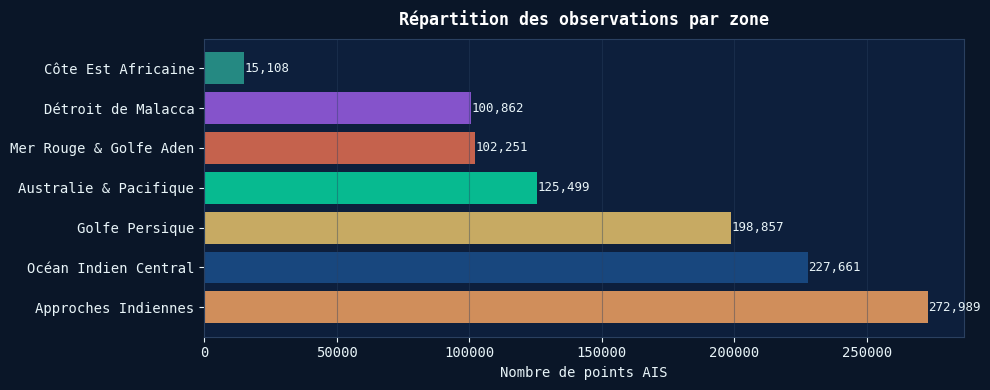

zone
Approches Indiennes       272989
Océan Indien Central      227661
Golfe Persique            198857
Australie & Pacifique     125499
Mer Rouge & Golfe Aden    102251
Détroit de Malacca        100862
Côte Est Africaine         15108
Name: count, dtype: int64


In [3]:
def assigner_zone(lat, lon):
    if lat > 12 and lon < 50:
        return 'Mer Rouge & Golfe Aden'
    elif lat > 20 and 50 <= lon <= 65:
        return 'Golfe Persique'
    elif lat < 12 and lon < 55 and lat > -15:
        return 'Côte Est Africaine'
    elif -10 <= lat <= 25 and 65 <= lon <= 85:
        return 'Approches Indiennes'
    elif lon > 95 and lat > -10:
        return 'Détroit de Malacca'
    elif lat < -20:
        return 'Australie & Pacifique'
    else:
        return 'Océan Indien Central'

df['zone'] = df.apply(lambda r: assigner_zone(r['latitude'], r['longitude']), axis=1)

# Distribution des zones
zone_counts = df['zone'].value_counts()
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(zone_counts.index, zone_counts.values,
               color=[ZONE_COLORS.get(z, TEAL) for z in zone_counts.index],
               alpha=0.85, edgecolor='none')
for bar, val in zip(bars, zone_counts.values):
    ax.text(val + 100, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9, color=LIGHT)
ax.set_title('Répartition des observations par zone', fontweight='bold', pad=10)
ax.set_xlabel('Nombre de points AIS')
ax.xaxis.grid(True)
plt.tight_layout()
plt.show()
print(zone_counts)

---
## 3. Statistiques Descriptives — Vitesse (SOG)

In [4]:
# ── Tableau complet par zone ──────────────────────────────────────
grp = df.groupby('zone')['sog']

table_sog = grp.agg(
    N='count',
    Moyenne='mean',
    Médiane='median',
    Écart_type='std',
    Min='min',
    P10=lambda x: x.quantile(0.10),
    P25=lambda x: x.quantile(0.25),
    P75=lambda x: x.quantile(0.75),
    P90=lambda x: x.quantile(0.90),
    P95=lambda x: x.quantile(0.95),
    Max='max',
).round(3)

table_sog['CV (%)']     = (table_sog['Écart_type'] / table_sog['Moyenne'] * 100).round(1)
table_sog['IQR']        = (table_sog['P75'] - table_sog['P25']).round(3)
table_sog['Asymétrie']  = grp.apply(lambda x: x.skew()).round(3)
table_sog['Kurtosis']   = grp.apply(lambda x: x.kurtosis()).round(3)

print('📊 Statistiques SOG (nœuds) par zone\n')
display(table_sog)
table_sog.to_csv('stats_sog_par_zone.csv', encoding='utf-8-sig')
print('\n💾 Exporté : stats_sog_par_zone.csv')

📊 Statistiques SOG (nœuds) par zone



,N,Moyenne,Médiane,Écart_type,Min,P10,P25,P75,P90,P95,Max,CV (%),IQR,Asymétrie,Kurtosis
zone,,,,,,,,,,,,,,,
Approches Indiennes,272989,15.674,16.600,4.031,0.100,11.100,14.452,18.300,19.260,19.800,29.868,25.7,3.848,-1.849,4.138
Australie & Pacifique,125499,15.475,16.054,3.143,0.100,11.429,13.946,17.698,18.800,19.364,29.543,20.3,3.752,-1.249,2.563
Côte Est Africaine,15108,15.102,16.000,4.188,0.133,10.769,14.081,17.733,18.946,19.409,28.805,27.7,3.652,-1.860,3.684
Détroit de Malacca,100862,15.435,16.200,4.090,0.100,11.000,14.002,18.013,19.250,19.946,29.780,26.5,4.011,-1.637,3.620
Golfe Persique,198857,12.928,15.200,6.151,0.100,1.350,10.133,17.494,18.828,19.365,29.808,47.6,7.361,-0.965,-0.413
Mer Rouge & Golfe Aden,102251,15.465,16.800,4.489,0.100,8.946,14.300,18.422,19.399,19.929,29.909,29.0,4.122,-1.675,2.587
Océan Indien Central,227661,16.078,16.700,3.222,0.100,12.151,14.800,18.183,19.207,19.834,29.774,20.0,3.383,-1.581,4.551



💾 Exporté : stats_sog_par_zone.csv


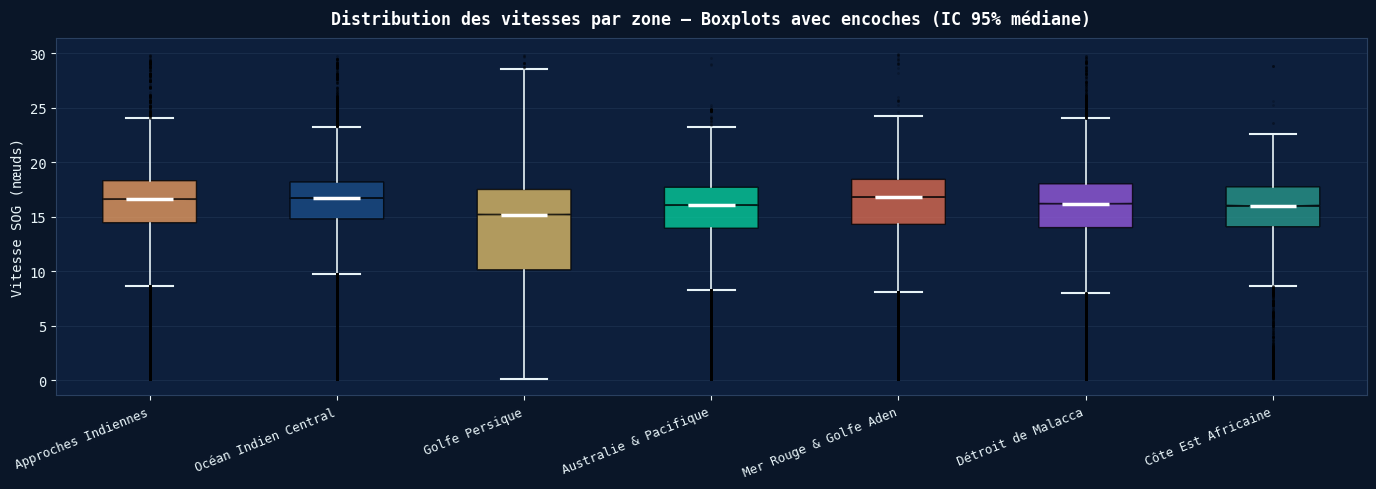

In [5]:
# ── Boxplots comparatifs ──────────────────────────────────────────
zones = list(df['zone'].value_counts().index)
data_zones = [df[df['zone'] == z]['sog'].dropna().values for z in zones]
couleurs = [ZONE_COLORS.get(z, TEAL) for z in zones]

fig, ax = plt.subplots(figsize=(14, 5))
bp = ax.boxplot(data_zones, patch_artist=True, notch=True,
                medianprops=dict(color='white', linewidth=2.5),
                whiskerprops=dict(color=LIGHT, linewidth=1.2),
                capprops=dict(color=LIGHT, linewidth=1.5),
                flierprops=dict(marker='.', markersize=2, alpha=0.2, color=GOLD))
for patch, c in zip(bp['boxes'], couleurs):
    patch.set_facecolor(c)
    patch.set_alpha(0.75)

ax.set_xticks(range(1, len(zones)+1))
ax.set_xticklabels(zones, rotation=22, ha='right', fontsize=9)
ax.set_ylabel('Vitesse SOG (nœuds)')
ax.set_title('Distribution des vitesses par zone — Boxplots avec encoches (IC 95% médiane)',
             fontweight='bold', pad=10)
ax.yaxis.grid(True)
plt.tight_layout()
plt.savefig('boxplot_vitesse_zones.png', dpi=150, bbox_inches='tight')
plt.show()

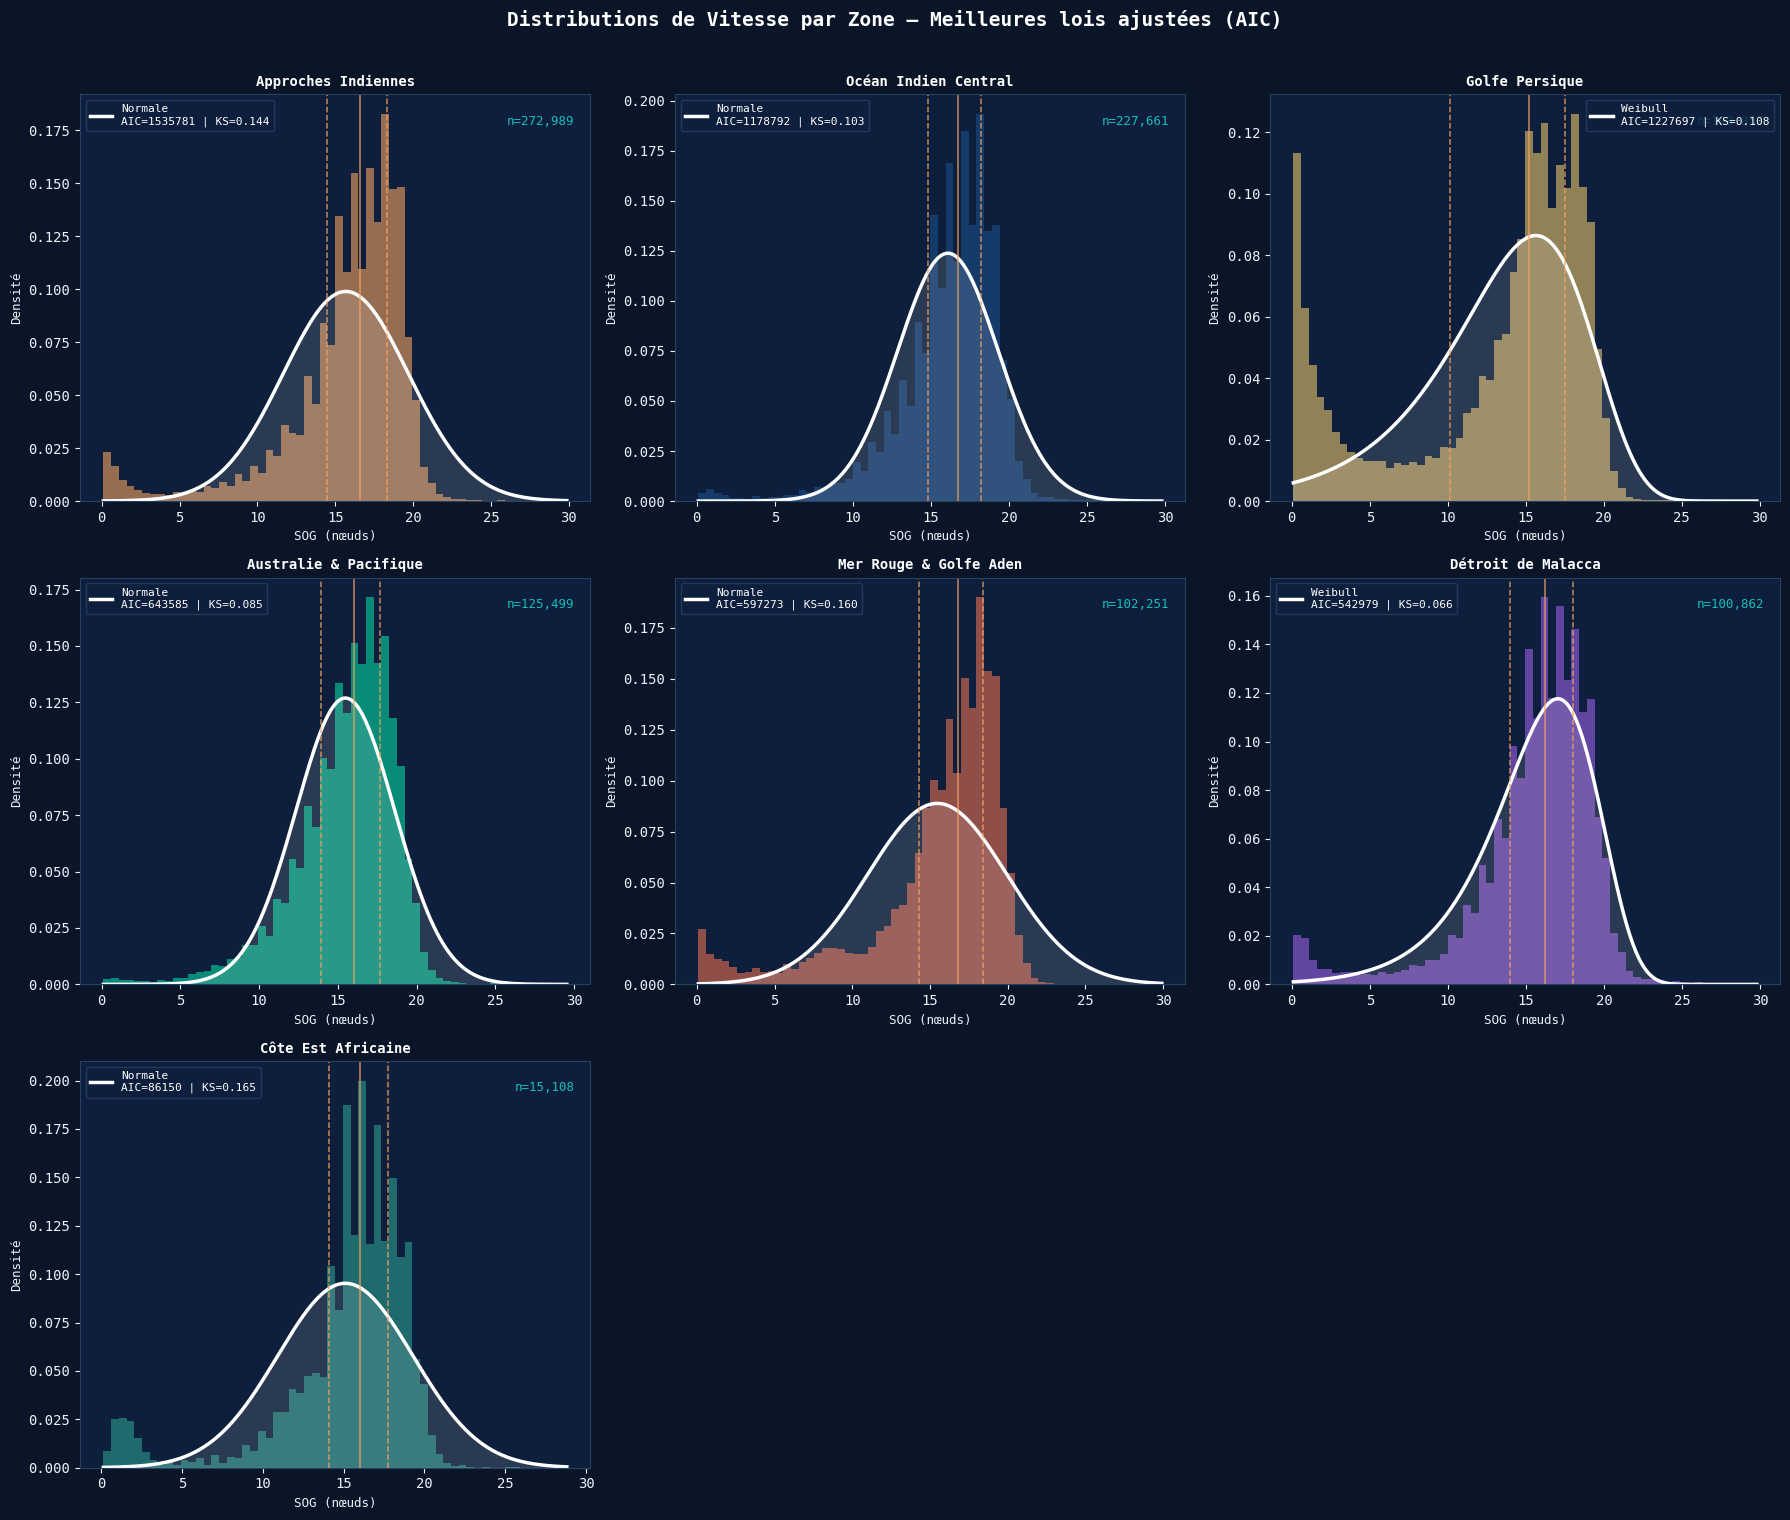


📋 Meilleures lois par zone :


,loi,AIC,KS,p
Approches Indiennes,Normale,1535781.0,0.1441,0.0
Océan Indien Central,Normale,1178791.8,0.1026,0.0
Golfe Persique,Weibull,1227697.0,0.1082,0.0
Australie & Pacifique,Normale,643585.3,0.0848,0.0
Mer Rouge & Golfe Aden,Normale,597272.6,0.1602,0.0
Détroit de Malacca,Weibull,542979.0,0.0656,0.0
Côte Est Africaine,Normale,86150.4,0.1653,0.0


In [6]:
# ── Histogrammes + lois ajustées par zone ─────────────────────────
LOIS = {'Normale': norm, 'Log-Normale': lognorm, 'Gamma': gamma, 'Weibull': weibull_min}

ncols = 3
nrows = int(np.ceil(len(zones) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 5))
axes = axes.flatten()

resultats_lois = {}

for i, zone in enumerate(zones):
    ax = axes[i]
    data = df[df['zone'] == zone]['sog'].dropna().values
    c = couleurs[i]

    ax.hist(data, bins=60, density=True, alpha=0.6, color=c, edgecolor='none')

    # Ajustement & sélection par AIC
    best_name, best_aic = None, np.inf
    x = np.linspace(data.min(), data.max(), 300)
    for nom, loi in LOIS.items():
        try:
            params = loi.fit(data)
            ll = np.sum(loi.logpdf(data, *params))
            aic = 2 * len(params) - 2 * ll
            ks, pv = kstest(data, loi.cdf, args=params)
            if aic < best_aic:
                best_aic, best_name = aic, nom
                best_params, best_ks, best_pv = params, ks, pv
        except Exception:
            pass

    resultats_lois[zone] = {'loi': best_name, 'AIC': round(best_aic, 1),
                            'KS': round(best_ks, 4), 'p': round(best_pv, 4)}

    if best_name:
        y = LOIS[best_name].pdf(x, *best_params)
        ax.plot(x, y, color='white', lw=2.5, label=f'{best_name}\nAIC={best_aic:.0f} | KS={best_ks:.3f}')
        ax.fill_between(x, y, alpha=0.12, color='white')

    for q, ls in [(0.25,'--'), (0.5,'-'), (0.75,'--')]:
        ax.axvline(np.quantile(data, q), color=GOLD, lw=1.1, ls=ls, alpha=0.8)

    ax.set_title(zone, fontweight='bold', fontsize=10)
    ax.set_xlabel('SOG (nœuds)', fontsize=9)
    ax.set_ylabel('Densité', fontsize=9)
    ax.legend(fontsize=8)
    ax.text(0.97, 0.95, f'n={len(data):,}', transform=ax.transAxes,
            ha='right', va='top', color=CYAN, fontsize=9)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Distributions de Vitesse par Zone — Meilleures lois ajustées (AIC)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('distributions_vitesse.png', dpi=150, bbox_inches='tight')
plt.show()

# Tableau récap
print('\n📋 Meilleures lois par zone :')
display(pd.DataFrame(resultats_lois).T)

---
## 4. Statistiques Descriptives — Conditions Météo

In [7]:
METEO_VARS = {
    'significant wave height Hs (m)': 'Hauteur vague Hs (m)',
    'wave period Tp (s)':             'Période vague Tp (s)',
    'wind_speed':                     'Vitesse vent (m/s)',
    'mean wave direction (°)':        'Direction vague (°)',
    'temp_air_C':                     'Temp. air (°C)',
    'temp_mer_C':                     'Temp. mer (°C)',
}

cols_ok = [c for c in METEO_VARS if c in df.columns]
rename  = {c: METEO_VARS[c] for c in cols_ok}

table_meteo = df[cols_ok].rename(columns=rename).describe().T
table_meteo['skewness'] = df[cols_ok].skew().values.round(3)
table_meteo['kurtosis'] = df[cols_ok].kurtosis().values.round(3)
table_meteo = table_meteo.round(3)

print('🌊 Statistiques météorologiques globales\n')
display(table_meteo)
table_meteo.to_csv('stats_meteo.csv', encoding='utf-8-sig')

🌊 Statistiques météorologiques globales



,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
Hauteur vague Hs (m),971648.0,1.484,1.006,0.000,0.710,1.299,2.134,10.124,0.856,0.815
Période vague Tp (s),971698.0,10.034,4.108,-3.949,6.502,10.501,12.996,25.548,-0.074,-0.666
Vitesse vent (m/s),1008575.0,5.540,2.944,0.003,3.223,5.241,7.533,26.177,0.505,-0.154
Direction vague (°),971698.0,190.491,73.345,-232.571,144.063,185.858,229.061,575.419,0.157,-0.225
Temp. air (°C),1008575.0,26.443,3.215,4.582,25.175,27.001,28.196,43.039,-0.828,1.727
Temp. mer (°C),949743.0,27.678,2.845,13.142,26.233,28.475,29.452,35.566,-1.013,1.323


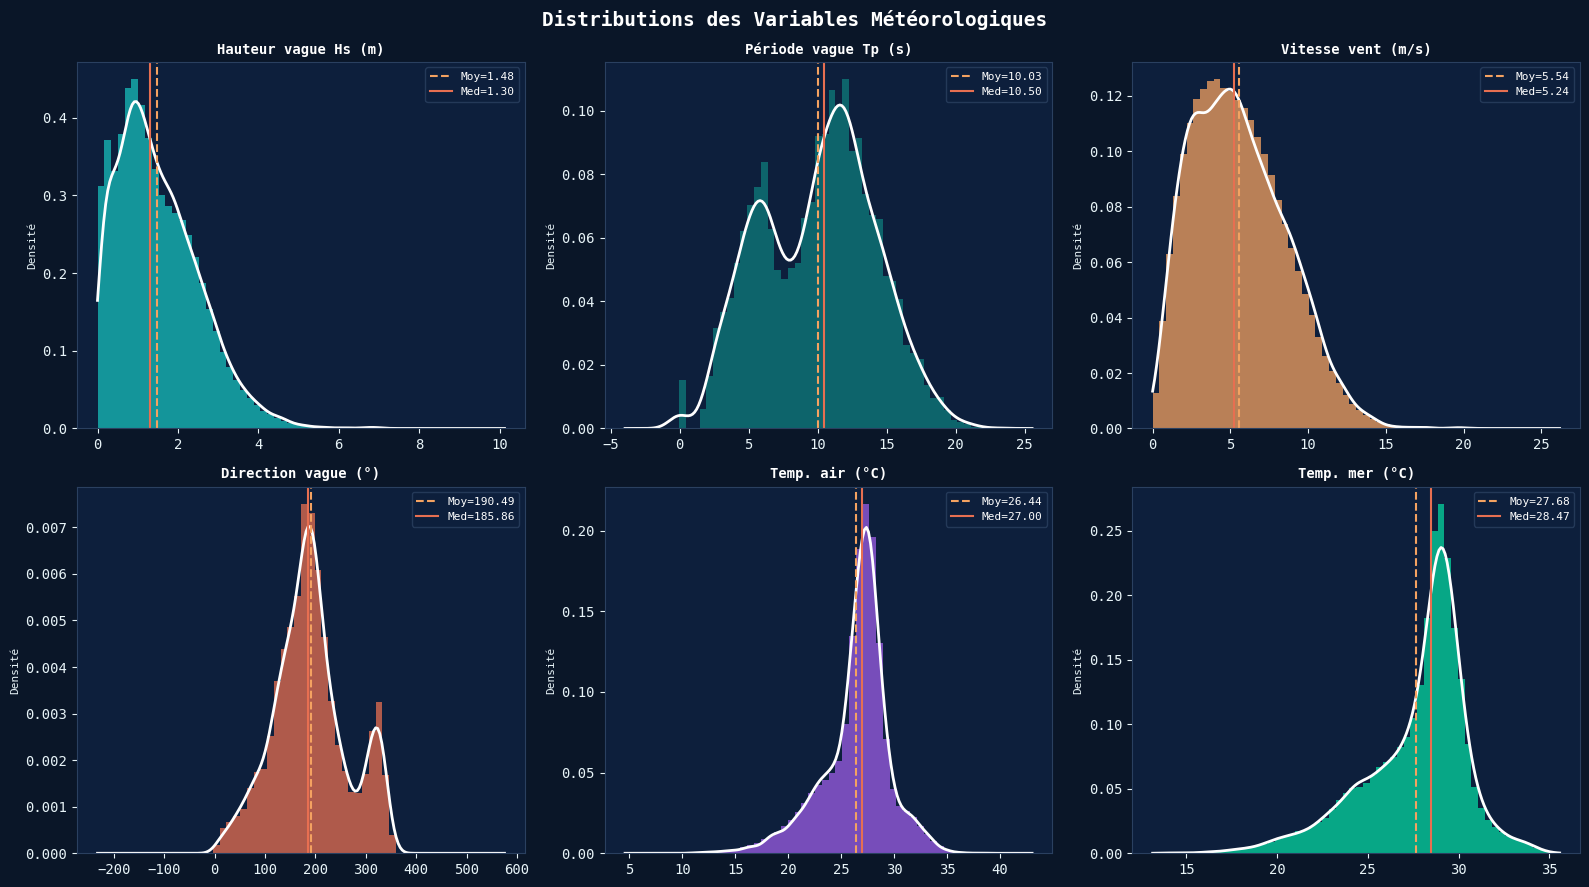

In [8]:
# ── Distributions météo ────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
meteo_colors = [CYAN, TEAL, GOLD, CORAL, '#9B5DE5', '#06D6A0']

for i, (col, label) in enumerate(zip(cols_ok[:6], list(rename.values())[:6])):
    ax = axes[i]
    data = df[col].dropna()
    ax.hist(data, bins=60, density=True, color=meteo_colors[i], alpha=0.75, edgecolor='none')

    # KDE
    kde_x = np.linspace(data.min(), data.max(), 200)
    kde = stats.gaussian_kde(data.sample(min(5000, len(data)), random_state=42))
    ax.plot(kde_x, kde(kde_x), color='white', lw=2)

    ax.axvline(data.mean(),   color=GOLD,  lw=1.5, ls='--', label=f'Moy={data.mean():.2f}')
    ax.axvline(data.median(), color=CORAL, lw=1.5, ls='-',  label=f'Med={data.median():.2f}')
    ax.set_title(label, fontweight='bold', fontsize=10)
    ax.set_ylabel('Densité', fontsize=8)
    ax.legend(fontsize=8)

fig.suptitle('Distributions des Variables Météorologiques', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('distributions_meteo.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Statistiques Descriptives — Draft (Tirant d'eau)

Draft — 1,032,253 observations valides (hors 0 et aberrants)
count    1032253.000
mean          10.571
std            1.241
min            1.000
25%            9.500
50%           10.500
75%           11.500
max           25.000
Name: draft, dtype: float64
Asymétrie : 0.837 | Kurtosis : 4.279


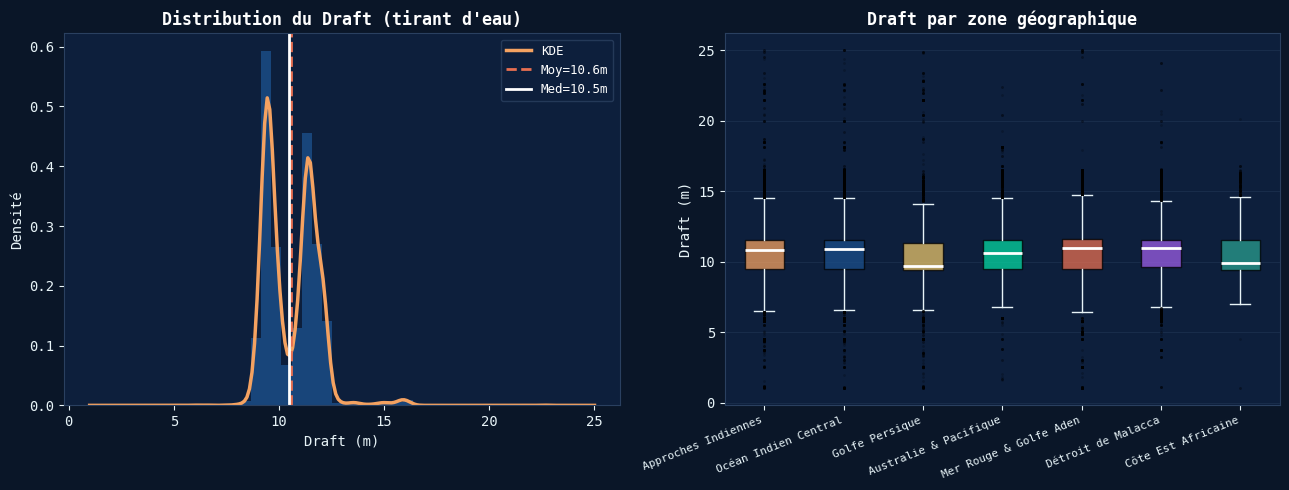

In [9]:
draft = df['draft'].replace(0, np.nan).dropna()
draft = draft[draft.between(1, 25)]  # filtrer valeurs aberrantes

print(f'Draft — {len(draft):,} observations valides (hors 0 et aberrants)')
print(draft.describe().round(3))
print(f'Asymétrie : {draft.skew():.3f} | Kurtosis : {draft.kurtosis():.3f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogramme
ax = axes[0]
ax.hist(draft, bins=50, density=True, color=OCEAN, alpha=0.8, edgecolor='none')
kde_x = np.linspace(draft.min(), draft.max(), 200)
kde = stats.gaussian_kde(draft.sample(min(5000, len(draft)), random_state=42))
ax.plot(kde_x, kde(kde_x), color=GOLD, lw=2.5, label='KDE')
ax.axvline(draft.mean(),   color=CORAL, lw=2, ls='--', label=f'Moy={draft.mean():.1f}m')
ax.axvline(draft.median(), color='white', lw=2, ls='-',  label=f'Med={draft.median():.1f}m')
ax.set_title('Distribution du Draft (tirant d\'eau)', fontweight='bold')
ax.set_xlabel('Draft (m)')
ax.set_ylabel('Densité')
ax.legend(fontsize=9)

# Draft par zone
ax2 = axes[1]
draft_zone = df[['zone', 'draft']].copy()
draft_zone['draft'] = draft_zone['draft'].replace(0, np.nan)
draft_zone = draft_zone[draft_zone['draft'].between(1, 25)]
data_z = [draft_zone[draft_zone['zone'] == z]['draft'].dropna().values for z in zones]
bp2 = ax2.boxplot(data_z, patch_artist=True,
                  medianprops=dict(color='white', lw=2),
                  whiskerprops=dict(color=LIGHT),
                  capprops=dict(color=LIGHT),
                  flierprops=dict(marker='.', alpha=0.2, color=GOLD, markersize=2))
for patch, c in zip(bp2['boxes'], couleurs):
    patch.set_facecolor(c)
    patch.set_alpha(0.75)
ax2.set_xticks(range(1, len(zones)+1))
ax2.set_xticklabels(zones, rotation=22, ha='right', fontsize=8)
ax2.set_ylabel('Draft (m)')
ax2.set_title('Draft par zone géographique', fontweight='bold')
ax2.yaxis.grid(True)

plt.tight_layout()
plt.savefig('draft_analyse.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Matrice de Corrélations

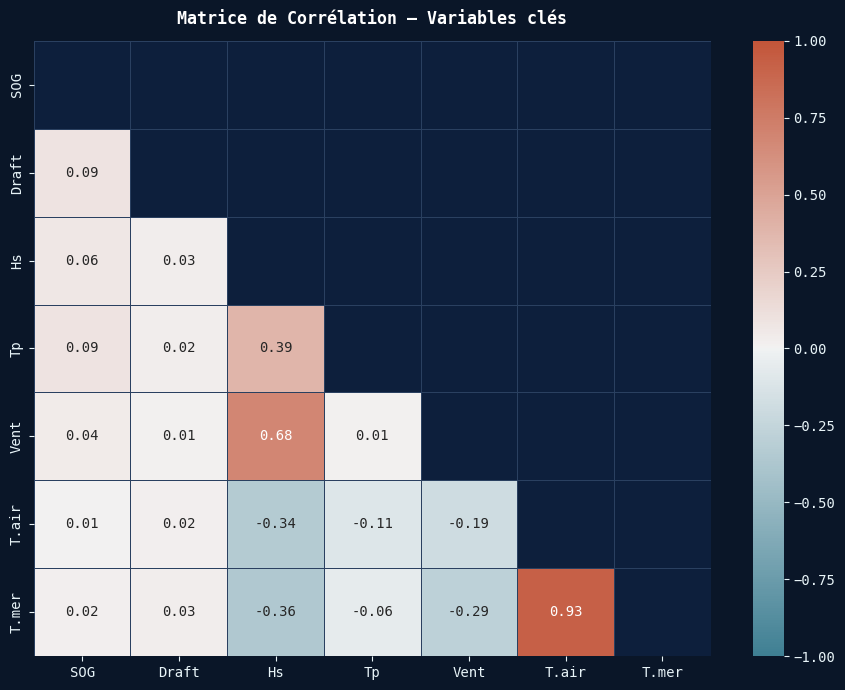


📊 Corrélations avec la vitesse SOG :
wave period Tp (s)                0.093
draft                             0.091
significant wave height Hs (m)    0.063
wind_speed                        0.043
temp_mer_C                        0.022
temp_air_C                        0.007
Name: sog, dtype: float64


In [10]:
corr_vars = ['sog', 'draft', 'significant wave height Hs (m)',
             'wave period Tp (s)', 'wind_speed', 'temp_air_C', 'temp_mer_C']
corr_vars = [c for c in corr_vars if c in df.columns]
labels    = ['SOG', 'Draft', 'Hs', 'Tp', 'Vent', 'T.air', 'T.mer']

corr_matrix = df[corr_vars].corr()

fig, ax = plt.subplots(figsize=(9, 7))
cmap = sns.diverging_palette(220, 20, as_cmap=True)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap=cmap, vmin=-1, vmax=1,
            center=0, annot=True, fmt='.2f', linewidths=0.5,
            linecolor='#2A4060', ax=ax,
            xticklabels=labels[:len(corr_vars)],
            yticklabels=labels[:len(corr_vars)])
ax.set_title('Matrice de Corrélation — Variables clés', fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('matrice_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# Corrélations avec SOG triées
print('\n📊 Corrélations avec la vitesse SOG :')
print(corr_matrix['sog'].drop('sog').sort_values(key=abs, ascending=False).round(3))

---
## 7. Séries Temporelles & Saisonnalité

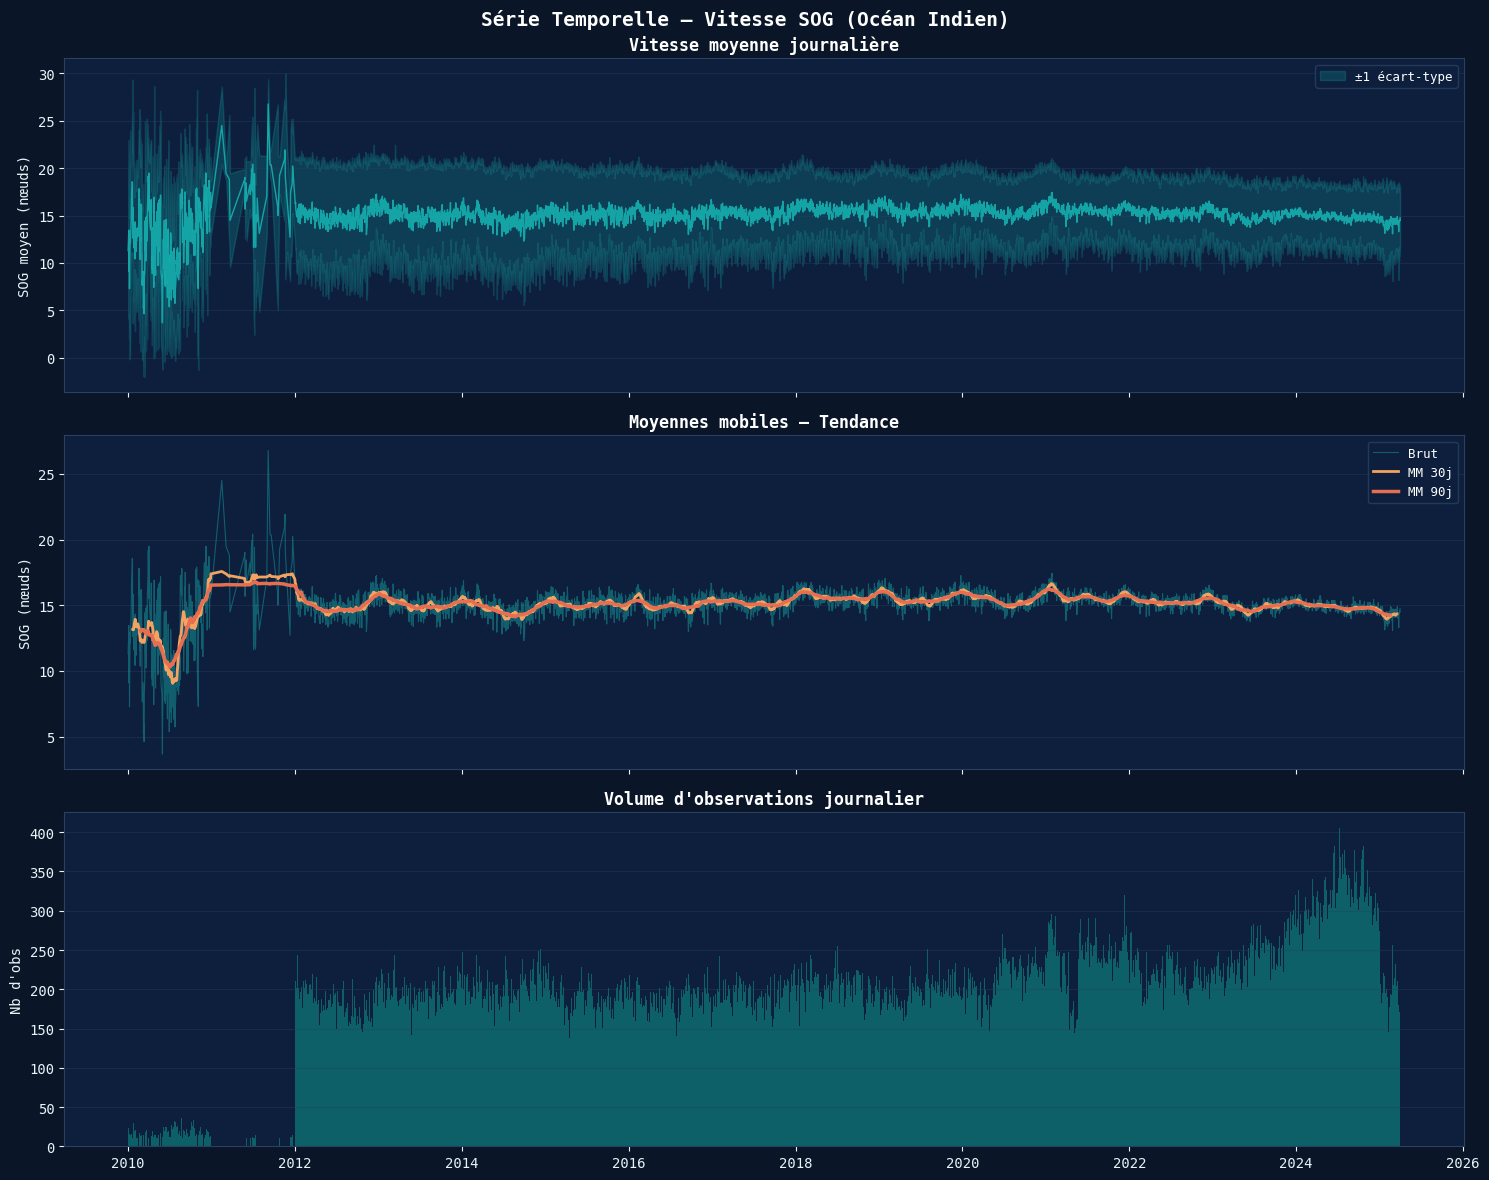

In [11]:
# ── Vitesse moyenne journalière ────────────────────────────────────
ts_daily = df.set_index('timestamp')['sog'].resample('D').agg(['mean', 'std', 'count'])
ts_daily = ts_daily[ts_daily['count'] >= 10]  # garder jours avec assez d'obs

fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)

# Série brute
ax = axes[0]
ax.plot(ts_daily.index, ts_daily['mean'], color=CYAN, lw=1, alpha=0.8)
ax.fill_between(ts_daily.index,
                ts_daily['mean'] - ts_daily['std'],
                ts_daily['mean'] + ts_daily['std'],
                alpha=0.2, color=CYAN, label='±1 écart-type')
ax.set_ylabel('SOG moyen (nœuds)')
ax.set_title('Vitesse moyenne journalière', fontweight='bold')
ax.legend(fontsize=9)
ax.yaxis.grid(True)

# Moyenne mobile 30j
ax2 = axes[1]
ts_daily['ma30'] = ts_daily['mean'].rolling(30, center=True).mean()
ts_daily['ma90'] = ts_daily['mean'].rolling(90, center=True).mean()
ax2.plot(ts_daily.index, ts_daily['mean'], color=CYAN, lw=0.8, alpha=0.4, label='Brut')
ax2.plot(ts_daily.index, ts_daily['ma30'], color=GOLD, lw=2, label='MM 30j')
ax2.plot(ts_daily.index, ts_daily['ma90'], color=CORAL, lw=2.5, label='MM 90j')
ax2.set_ylabel('SOG (nœuds)')
ax2.set_title('Moyennes mobiles — Tendance', fontweight='bold')
ax2.legend(fontsize=9)
ax2.yaxis.grid(True)

# Volume d'observations
ax3 = axes[2]
ax3.bar(ts_daily.index, ts_daily['count'], color=TEAL, alpha=0.7, width=1, edgecolor='none')
ax3.set_ylabel("Nb d'obs")
ax3.set_title("Volume d'observations journalier", fontweight='bold')
ax3.yaxis.grid(True)

fig.suptitle('Série Temporelle — Vitesse SOG (Océan Indien)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('serie_temporelle_sog.png', dpi=150, bbox_inches='tight')
plt.show()

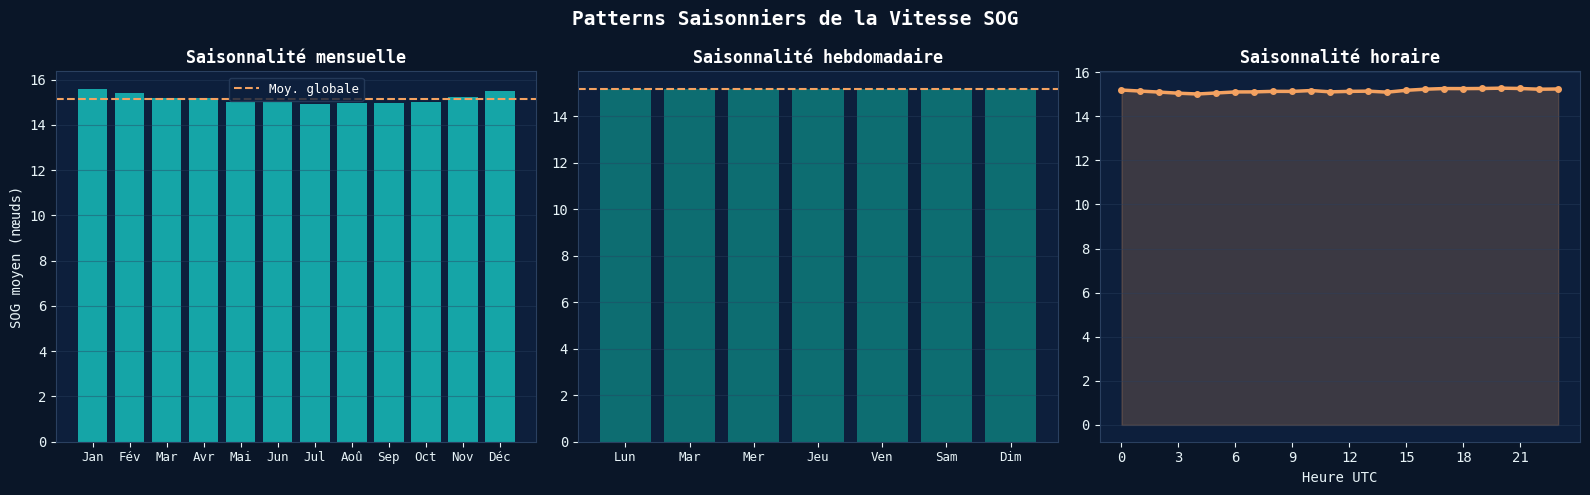

In [12]:
# ── Saisonnalité : par mois et par heure ──────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

MOIS = ['Jan','Fév','Mar','Avr','Mai','Jun','Jul','Aoû','Sep','Oct','Nov','Déc']
JOURS = ['Lun','Mar','Mer','Jeu','Ven','Sam','Dim']

# Par mois
ax = axes[0]
sog_mois = df.groupby('month')['sog'].mean()
ax.bar(range(1, 13), sog_mois.values, color=CYAN, alpha=0.85, edgecolor='none')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(MOIS, fontsize=9)
ax.set_ylabel('SOG moyen (nœuds)')
ax.set_title('Saisonnalité mensuelle', fontweight='bold')
ax.yaxis.grid(True)
ax.axhline(sog_mois.mean(), color=GOLD, lw=1.5, ls='--', label='Moy. globale')
ax.legend(fontsize=9)

# Par jour de semaine
ax2 = axes[1]
sog_jour = df.groupby('weekday')['sog'].mean()
ax2.bar(range(7), sog_jour.values, color=TEAL, alpha=0.85, edgecolor='none')
ax2.set_xticks(range(7))
ax2.set_xticklabels(JOURS, fontsize=9)
ax2.set_title('Saisonnalité hebdomadaire', fontweight='bold')
ax2.yaxis.grid(True)
ax2.axhline(sog_jour.mean(), color=GOLD, lw=1.5, ls='--')

# Par heure
ax3 = axes[2]
sog_heure = df.groupby('hour')['sog'].mean()
ax3.plot(sog_heure.index, sog_heure.values, color=GOLD, lw=2.5, marker='o', markersize=4)
ax3.fill_between(sog_heure.index, sog_heure.values, alpha=0.2, color=GOLD)
ax3.set_xlabel('Heure UTC')
ax3.set_title('Saisonnalité horaire', fontweight='bold')
ax3.yaxis.grid(True)
ax3.set_xticks(range(0, 24, 3))

fig.suptitle('Patterns Saisonniers de la Vitesse SOG', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('saisonnalite_sog.png', dpi=150, bbox_inches='tight')
plt.show()

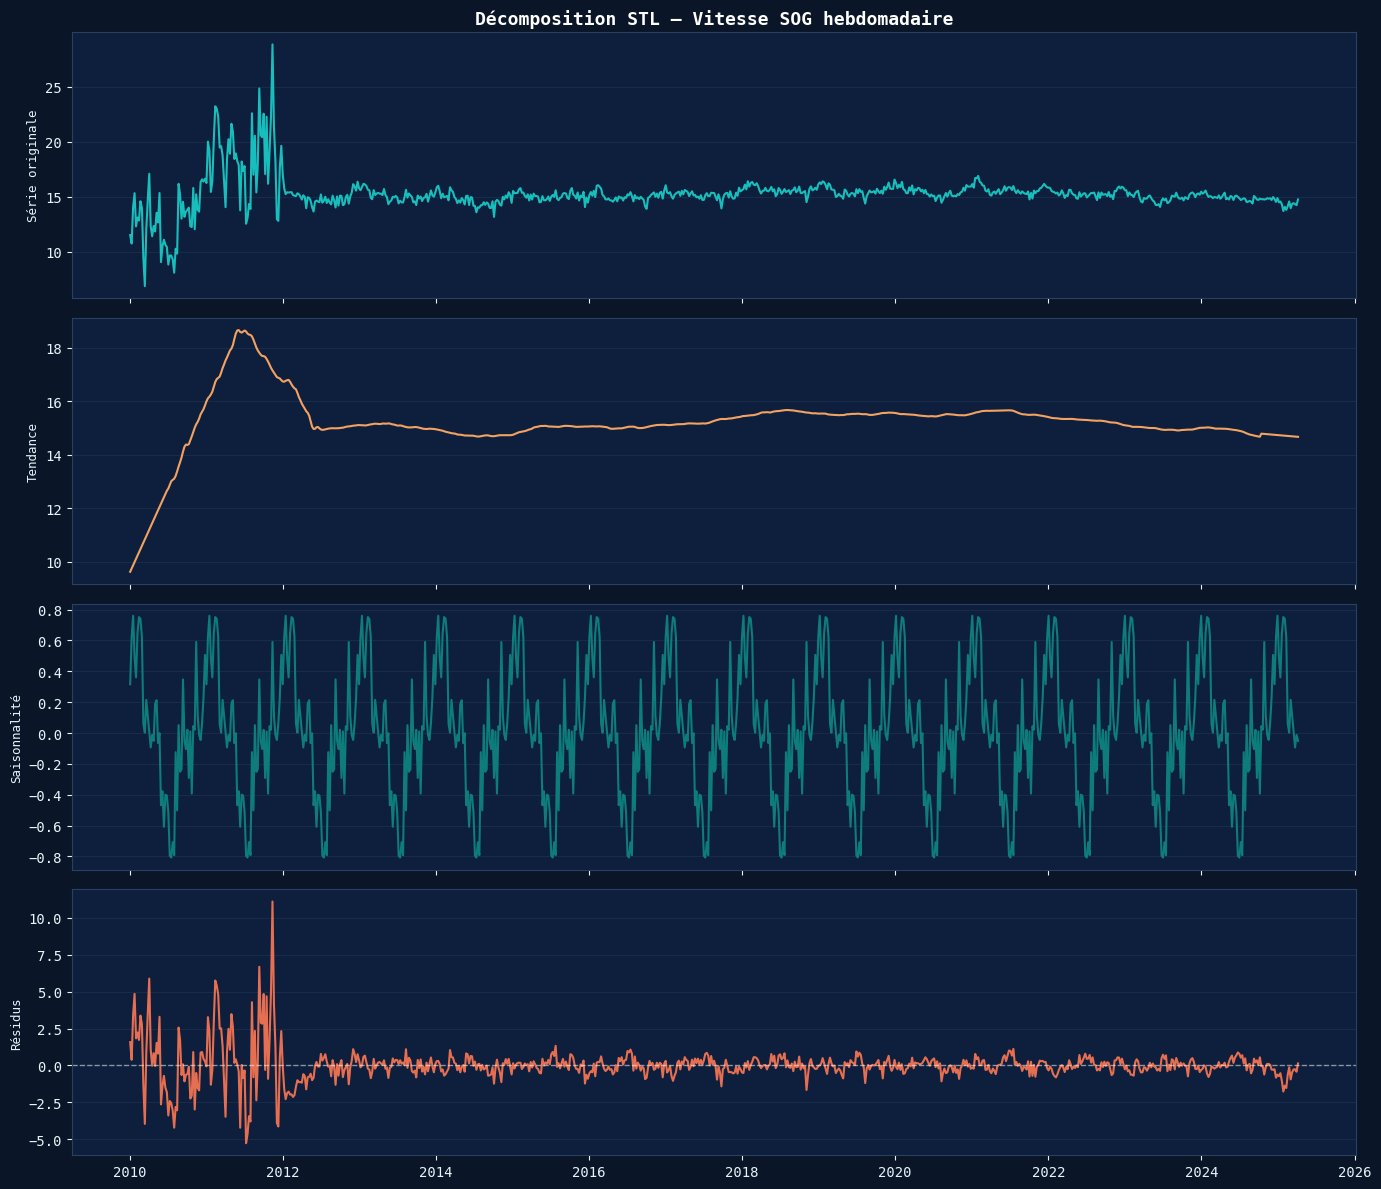

In [13]:
# ── Décomposition STL (tendance / saisonnalité / résidus) ─────────
ts_weekly = df.set_index('timestamp')['sog'].resample('W').mean().dropna()

if len(ts_weekly) >= 24:
    decomp = seasonal_decompose(ts_weekly, model='additive', period=52, extrapolate_trend='freq')

    fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
    components = [
        (ts_weekly,         'Série originale',  CYAN),
        (decomp.trend,      'Tendance',         GOLD),
        (decomp.seasonal,   'Saisonnalité',     TEAL),
        (decomp.resid,      'Résidus',          CORAL),
    ]
    for ax, (series, title, color) in zip(axes, components):
        ax.plot(series.index, series.values, color=color, lw=1.5)
        if title == 'Résidus':
            ax.axhline(0, color='white', lw=1, ls='--', alpha=0.5)
        ax.set_ylabel(title, fontsize=9)
        ax.yaxis.grid(True)

    axes[0].set_title('Décomposition STL — Vitesse SOG hebdomadaire',
                      fontweight='bold', fontsize=13)
    plt.tight_layout()
    plt.savefig('decomposition_stl.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('⚠️ Pas assez de semaines pour la décomposition STL (besoin ≥ 24)')

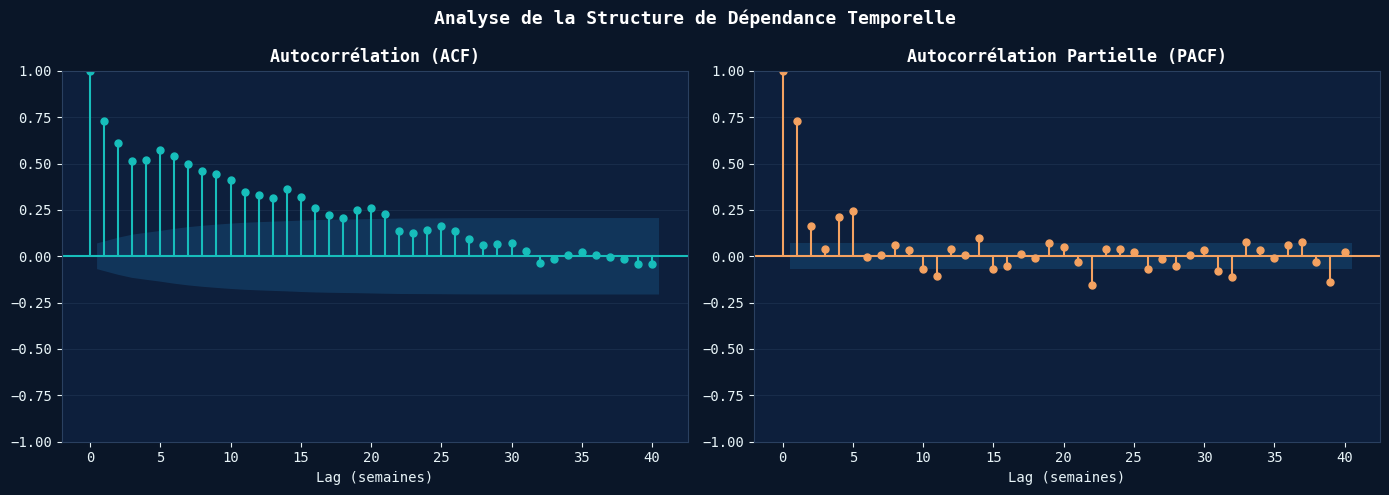


📉 Test de Dickey-Fuller Augmenté (stationnarité)
   Statistique ADF : -4.8705
   p-value         : 0.0000
   Valeurs critiques: {'1%': np.float64(-3.4388159246521433), '5%': np.float64(-2.865276554696385), '10%': np.float64(-2.5687597090530696)}
   ✅ Série STATIONNAIRE (p < 0.05) → ARMA applicable directement


In [14]:
# ── ACF / PACF — Préparation modèles ARMA ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(ts_weekly.dropna(), lags=40, ax=axes[0],
         color=CYAN, vlines_kwargs={'colors': CYAN})
axes[0].set_title('Autocorrélation (ACF)', fontweight='bold')

plot_pacf(ts_weekly.dropna(), lags=40, ax=axes[1], method='ywm',
          color=GOLD, vlines_kwargs={'colors': GOLD})
axes[1].set_title('Autocorrélation Partielle (PACF)', fontweight='bold')

for ax in axes:
    ax.set_xlabel('Lag (semaines)')
    ax.yaxis.grid(True)

fig.suptitle('Analyse de la Structure de Dépendance Temporelle',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Test de stationnarité ADF ──────────────────────────────────────
adf_stat, adf_p, _, _, adf_crit, _ = adfuller(ts_weekly.dropna())
print('\n📉 Test de Dickey-Fuller Augmenté (stationnarité)')
print(f'   Statistique ADF : {adf_stat:.4f}')
print(f'   p-value         : {adf_p:.4f}')
print(f'   Valeurs critiques: {adf_crit}')
if adf_p < 0.05:
    print('   ✅ Série STATIONNAIRE (p < 0.05) → ARMA applicable directement')
else:
    print('   ⚠️  Série NON stationnaire → différenciation nécessaire (ARIMA)')

---
## 8. Tests Statistiques Formels

📊 Test de Kruskal-Wallis — H0: distributions identiques entre zones
   Statistique H = 32959.18 | p-value = 0.00e+00
   ✅ Rejet H0 : les vitesses diffèrent significativement entre zones


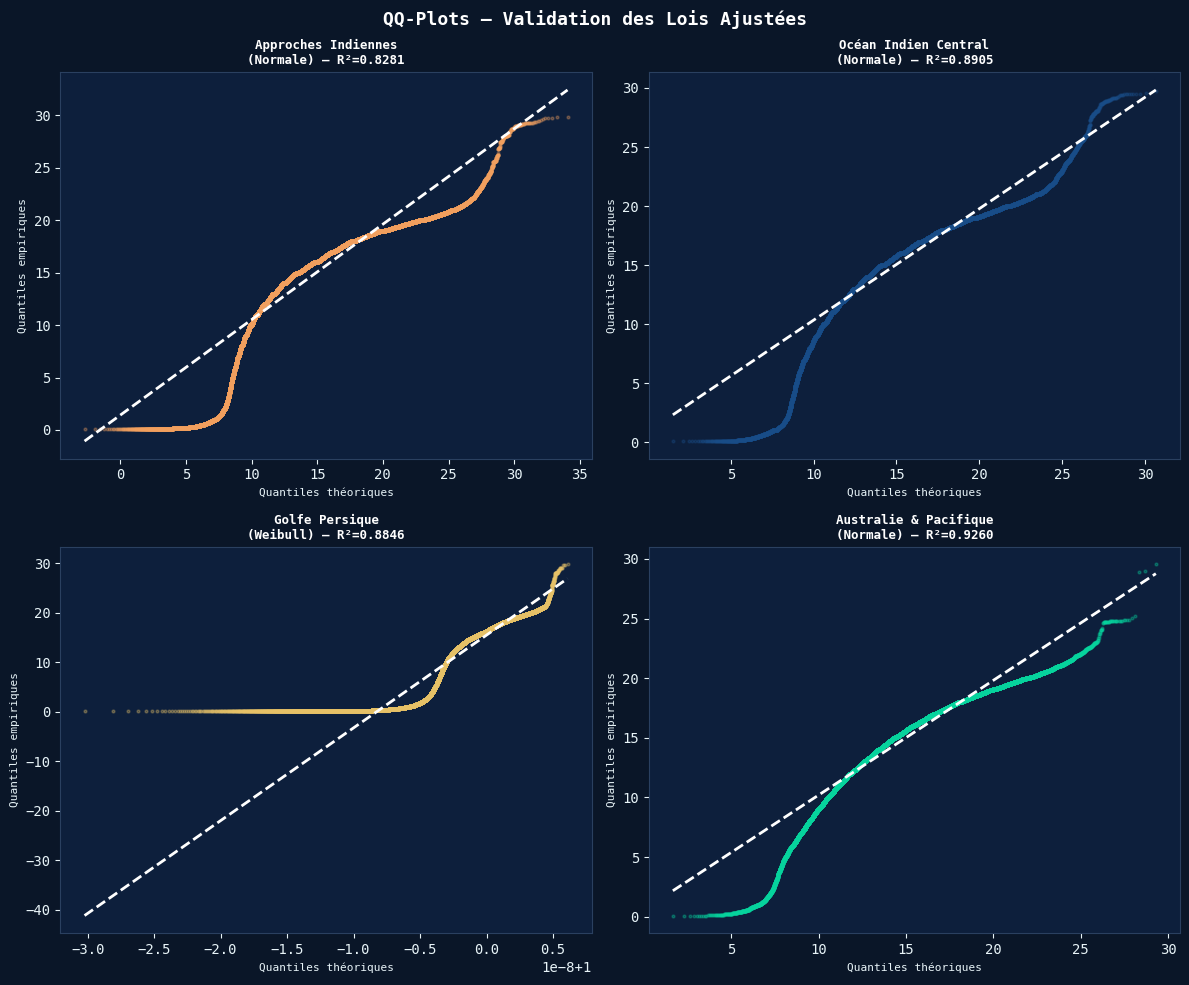

In [15]:
from scipy.stats import kruskal, mannwhitneyu

# ── Test de Kruskal-Wallis : vitesse différente entre zones ? ──────
groups = [df[df['zone'] == z]['sog'].dropna().values for z in zones]
stat, p = kruskal(*groups)
print('📊 Test de Kruskal-Wallis — H0: distributions identiques entre zones')
print(f'   Statistique H = {stat:.2f} | p-value = {p:.2e}')
if p < 0.05:
    print('   ✅ Rejet H0 : les vitesses diffèrent significativement entre zones')

# ── QQ-plots par zone (validation des lois) ───────────────────────
n_zones = min(4, len(zones))
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, zone in enumerate(zones[:n_zones]):
    ax = axes[i]
    data = df[df['zone'] == zone]['sog'].dropna().values
    loi_name = resultats_lois.get(zone, {}).get('loi', 'norm')
    loi = LOIS.get(loi_name, norm)

    try:
        params = loi.fit(data)
        (osm, osr), (slope, intercept, r) = stats.probplot(data, dist=loi,
                                                            sparams=params[:-2] if len(params) > 2 else params)
    except Exception:
        (osm, osr), (slope, intercept, r) = stats.probplot(data)

    ax.scatter(osm, osr, alpha=0.3, s=4, color=couleurs[i])
    ax.plot([osm.min(), osm.max()],
            [slope*osm.min()+intercept, slope*osm.max()+intercept],
            color='white', lw=2, ls='--')
    ax.set_title(f'{zone}\n({loi_name}) — R²={r**2:.4f}', fontweight='bold', fontsize=9)
    ax.set_xlabel('Quantiles théoriques', fontsize=8)
    ax.set_ylabel('Quantiles empiriques', fontsize=8)

fig.suptitle('QQ-Plots — Validation des Lois Ajustées', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('qqplots.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Synthèse — Tableau de Bord Rapport

In [16]:
print('=' * 60)
print('  SYNTHÈSE — STATISTIQUES DESCRIPTIVES')
print('  Projet GTT x ENSAE — Océan Indien')
print('=' * 60)

print(f"""
DONNÉES
  Observations (nettoyées) : {len(df):,}
  Navires uniques           : {df['mmsi'].nunique():,}
  Période                   : {df['timestamp'].min().date()} → {df['timestamp'].max().date()}
  Zones géographiques       : {df['zone'].nunique()}

VITESSE (SOG)
  Moyenne globale           : {df['sog'].mean():.2f} nœuds
  Médiane                   : {df['sog'].median():.2f} nœuds
  Écart-type                : {df['sog'].std():.2f} nœuds
  CV                        : {df['sog'].std()/df['sog'].mean()*100:.1f}%
  Asymétrie                 : {df['sog'].skew():.3f}

CONDITIONS MÉTÉO
  Hs moyen                  : {df['significant wave height Hs (m)'].mean():.2f} m
  Vent moyen                : {df['wind_speed'].mean():.2f} m/s
  Temp. air moyenne         : {df['temp_air_C'].mean():.1f} °C

DRAFT
  Draft moyen (valide)      : {df['draft'][df['draft'].between(1,25)].mean():.2f} m
  Draft médian              : {df['draft'][df['draft'].between(1,25)].median():.2f} m
""")

print('\n📋 Meilleures lois par zone :')
display(pd.DataFrame(resultats_lois).T)

print('\n💾 Fichiers générés :')
fichiers = [
    'stats_sog_par_zone.csv', 'stats_meteo.csv',
    'boxplot_vitesse_zones.png', 'distributions_vitesse.png',
    'distributions_meteo.png', 'draft_analyse.png',
    'matrice_correlation.png', 'serie_temporelle_sog.png',
    'saisonnalite_sog.png', 'decomposition_stl.png',
    'acf_pacf.png', 'qqplots.png',
]
for f in fichiers:
    print(f'   ✅ {f}')

  SYNTHÈSE — STATISTIQUES DESCRIPTIVES
  Projet GTT x ENSAE — Océan Indien

DONNÉES
  Observations (nettoyées) : 1,043,227
  Navires uniques           : 890
  Période                   : 2010-01-01 → 2025-03-31
  Zones géographiques       : 7

VITESSE (SOG)
  Moyenne globale           : 15.16 nœuds
  Médiane                   : 16.23 nœuds
  Écart-type                : 4.47 nœuds
  CV                        : 29.5%
  Asymétrie                 : -1.697

CONDITIONS MÉTÉO
  Hs moyen                  : 1.48 m
  Vent moyen                : 5.54 m/s
  Temp. air moyenne         : 26.4 °C

DRAFT
  Draft moyen (valide)      : 10.57 m
  Draft médian              : 10.50 m


📋 Meilleures lois par zone :


,loi,AIC,KS,p
Approches Indiennes,Normale,1535781.0,0.1441,0.0
Océan Indien Central,Normale,1178791.8,0.1026,0.0
Golfe Persique,Weibull,1227697.0,0.1082,0.0
Australie & Pacifique,Normale,643585.3,0.0848,0.0
Mer Rouge & Golfe Aden,Normale,597272.6,0.1602,0.0
Détroit de Malacca,Weibull,542979.0,0.0656,0.0
Côte Est Africaine,Normale,86150.4,0.1653,0.0



💾 Fichiers générés :
   ✅ stats_sog_par_zone.csv
   ✅ stats_meteo.csv
   ✅ boxplot_vitesse_zones.png
   ✅ distributions_vitesse.png
   ✅ distributions_meteo.png
   ✅ draft_analyse.png
   ✅ matrice_correlation.png
   ✅ serie_temporelle_sog.png
   ✅ saisonnalite_sog.png
   ✅ decomposition_stl.png
   ✅ acf_pacf.png
   ✅ qqplots.png
